# Task 1: Environment, Data Acquisition, and Exploratory Analysis

**Objective:** Load the "Video Game Sales & Industry Data" dataset, perform a data quality audit, clean the data, and explore key patterns through 5 visualisations.
**Required Inputs:** `../data/raw/vg_sales.csv`
**Outputs Produced:** `../data/cleaned.csv`

**Dataset Description:**
This dataset contains historical sales data for video games, including platform, year of release, genre, publisher, and sales across different regions (North America, Europe, Japan, Global). I chose this dataset because the gaming industry has clear numerical targets (sales) and categorical features (genres/platforms) that are perfect for both regression and classification tasks later in the pipeline.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Define constants
RAW_DATA_PATH = '../data/raw/vg_sales.csv'
CLEAN_DATA_PATH = '../data/cleaned.csv'

### 1. Data Loading and Structure

In [32]:
df = pd.read_csv(RAW_DATA_PATH)

print(f"Row count: {df.shape[0]}")
print(f"Column count: {df.shape[1]}\n")
print("Data Types and Non-Null Counts:")
print(df.info())

display(df.head())

Row count: 64016
Column count: 14

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB
None


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


### 2. Data Quality Audit & Cleaning

In [33]:
print("--- Missing Values Before ---")
print(df.isnull().sum())
print(f"\nDuplicates before: {df.duplicated().sum()}")

df = df.drop_duplicates()

# Сначала удаляем строки, где вообще нет даты релиза
df = df.dropna(subset=['release_date'])

# Конвертируем строку в формат даты и вытаскиваем год
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date']) # удаляем, если дата была кривая и не сконвертировалась
df['year'] = df['release_date'].dt.year.astype(int)

# Фильтруем адекватные года (отбрасываем явный мусор)
df = df[(df['year'] >= 1980) & (df['year'] <= 2026)]

# 3. Чистим целевую переменную и важные фичи
# Нам обязательно нужны продажи для Task 2 и жанры/консоли
df = df.dropna(subset=['total_sales', 'genre', 'console'])

print("\n--- Missing Values After ---")
print(df.isnull().sum())
print(f"Current Row Count: {df.shape[0]}")

# Сохраняем для Task 2
import os
os.makedirs('../data', exist_ok=True)
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"\nCleaned data saved to {CLEAN_DATA_PATH}")

--- Missing Values Before ---
img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

Duplicates before: 0

--- Missing Values After ---
img                 0
title               0
console             0
genre               0
publisher           0
developer           3
critic_score    14698
total_sales         0
na_sales         6212
jp_sales        12133
pal_sales        6056
other_sales      3761
release_date        0
last_update     14805
year                0
dtype: int64
Current Row Count: 18821

Cleaned data saved to ../data/cleaned.csv


/tmp/ipykernel_319988/1638787415.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


### Exploratory Data Analysis (EDA)

<function matplotlib.pyplot.show(close=None, block=None)>

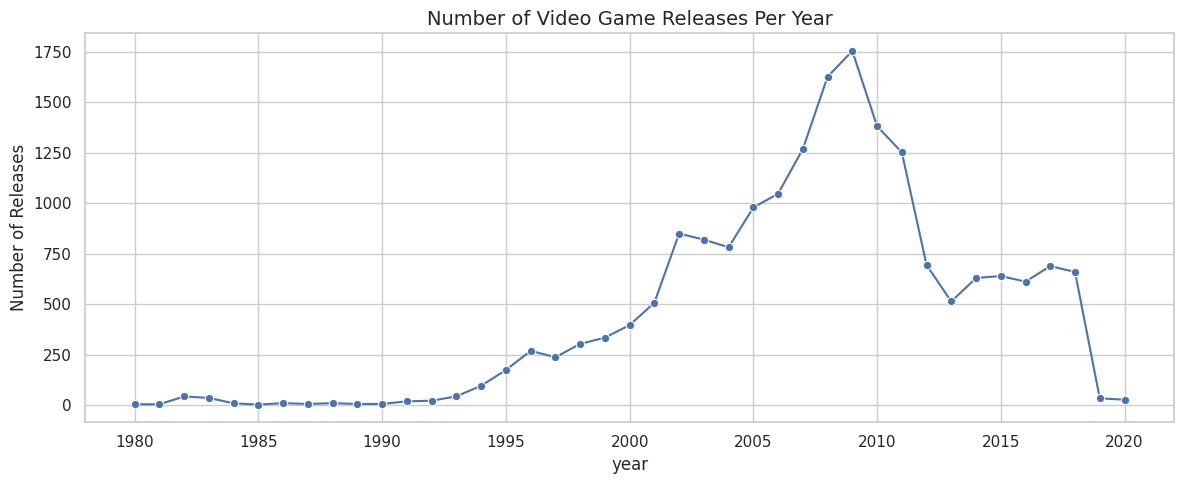

In [34]:
plt.figure(figsize=(12,5))
releases_per_year = df['year'].value_counts().sort_index()
sns.lineplot(x=releases_per_year.index, y=releases_per_year.values, marker='o', color='b')
plt.title("Number of Video Game Releases Per Year", fontsize=14)
plt.xlabel('year', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.tight_layout()
plt.savefig("../diagrams/Number of Video Game Releases Per Year.png")

plt.show


**Question 2: What are the most popular genres in the industry overall?**

/tmp/ipykernel_319988/339124806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='genre', order=order, palette='viridis')


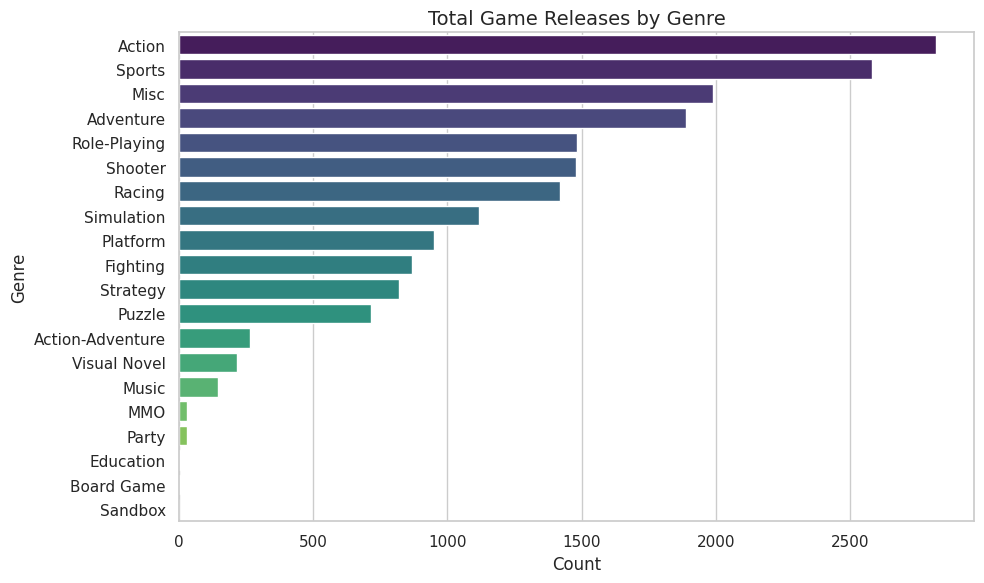

In [35]:
plt.figure(figsize=(10,6))
order = df['genre'].value_counts().index
sns.countplot(data=df, y='genre', order=order, palette='viridis')
plt.title('Total Game Releases by Genre', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.savefig("../diagrams/Total Game Releases by Genre.png")
plt.show()

**Question 3: Which platforms have generated the highest total global sales?**

/tmp/ipykernel_319988/2664417889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_sales.values, y=platform_sales.index, palette='magma')


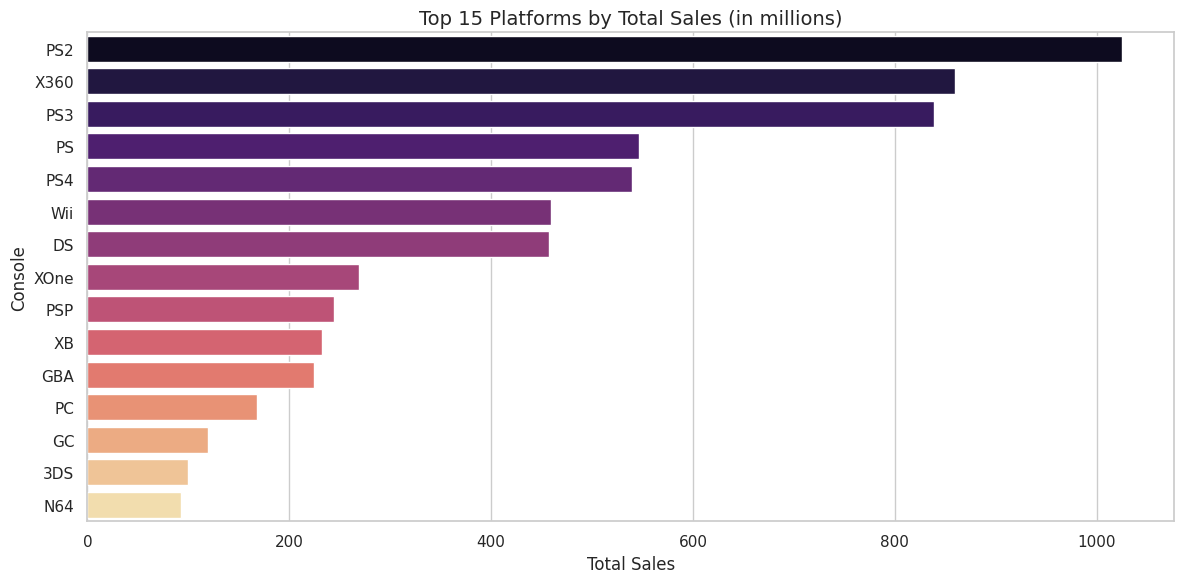

In [36]:
platform_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=platform_sales.values, y=platform_sales.index, palette='magma')
plt.title('Top 15 Platforms by Total Sales (in millions)', fontsize=14)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Console', fontsize=12)
plt.tight_layout()
plt.savefig("../diagrams/Top 15 Platforms by Total Sales (in millions).png")
plt.show()

**Question 4: What is the distribution of Global Sales?**

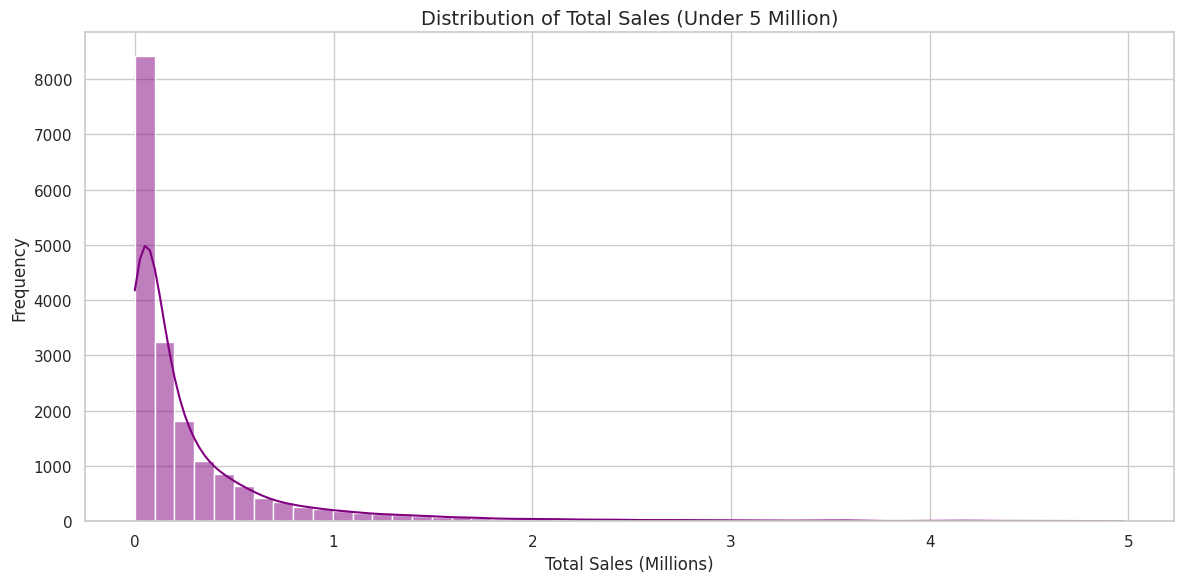

In [37]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['total_sales'] < 5]['total_sales'], bins=50, kde=True, color='purple')
plt.title('Distribution of Total Sales (Under 5 Million)', fontsize=14)
plt.xlabel('Total Sales (Millions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig("../diagrams/Distribution of Total Sales (Under 5 Million).png")
plt.show()

**Question 5: How do regional sales (North America vs. Europe) correlate with each other?**

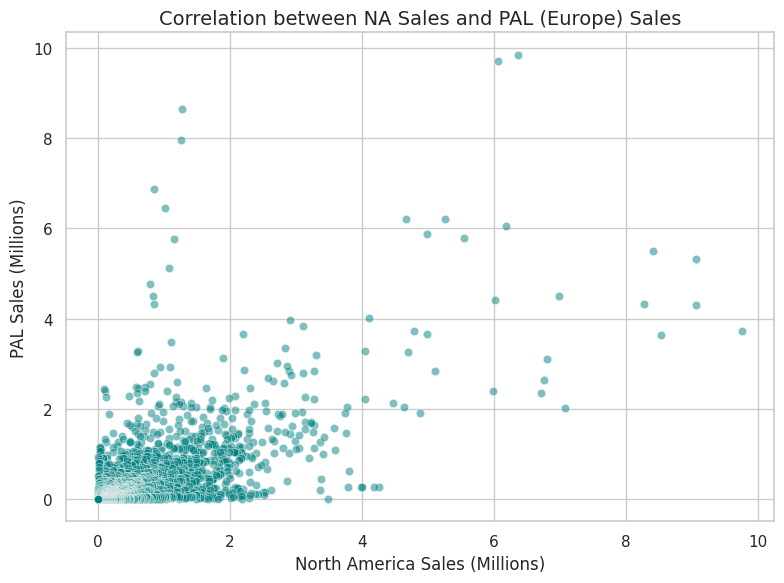

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df[(df['na_sales'] < 10) & (df['pal_sales'] < 10)], x='na_sales', y='pal_sales', alpha=0.5, color='teal')
plt.title('Correlation between NA Sales and PAL (Europe) Sales', fontsize=14)
plt.xlabel('North America Sales (Millions)', fontsize=12)
plt.ylabel('PAL Sales (Millions)', fontsize=12)
plt.tight_layout()
plt.savefig("../diagrams/Correlation between NA Sales and PAL (Europe) Sales.png")
plt.show()

### Summary

The exploratory data analysis revealed several key dynamics within the video game industry. First, game production peaked heavily around 2008-2010 before declining, likely due to the shift towards digital distribution and longer development cycles for "AAA" games. Action and Sports are the most saturated genres, while platforms like the PS2 and Xbox 360 dominate historical total sales. 

Crucially, the distribution of `Global_Sales` is extremely right-skewed. The vast majority of games sell under 500,000 copies, while a tiny fraction of outliers (the "mega-hits") skew the mean. This tells us that predicting exact sales (regression) in Task 2 will be challenging without a log-transformation, and predicting whether a game will be a "Hit" or "Flop" (classification) might be a more robust approach. Additionally, North American and European sales show a strong positive correlation, indicating that Western markets have similar tastes, whereas Japanese sales might require a separate analysis. The remaining question is whether we can accurately predict a game's commercial success using only its pre-release attributes like platform, genre, and publisher.